In [135]:
# Importy i ustawienia
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import seaborn as sns
np.random.seed(42)
torch.manual_seed(42)
print("Importy załadowane, seed ustawiony.")
cuda = torch.cuda.is_available()
print("CUDA dostępne:", cuda)

Importy załadowane, seed ustawiony.
CUDA dostępne: True


In [136]:
# Komórka 3: Funkcje do tokenizacji i BPE
def convert_text_to_bytes(text):
    return list(map(int, text.encode('utf-8')))
def merge_pair_single(token_list, pair_to_merge, new_token):
    new_list, i = [], 0
    while i < len(token_list):
        if i < len(token_list) - 1 and (token_list[i], token_list[i+1]) == pair_to_merge:
            new_list.append(new_token); i += 2
        else:
            new_list.append(token_list[i]); i += 1
    return new_list
def iterative_merge(token_list, num_iterations, start_token=256):
    new_token = start_token
    current_tokens = token_list
    for _ in range(num_iterations):
        stats = {}
        for pair in zip(current_tokens, current_tokens[1:]):
            stats[pair] = stats.get(pair, 0) + 1
        if not stats: break
        most_common_pair = max(stats, key=stats.get)
        current_tokens = merge_pair_single(current_tokens, most_common_pair, new_token)
        new_token += 1
    return current_tokens

print("Funkcje tokenizacji i BPE gotowe.")


Funkcje tokenizacji i BPE gotowe.


In [137]:
# Komórka 4: Implementacja Generatora i Dyskryminatora (PyTorch)
class LSTMGeneratorPyTorch(nn.Module):
    def __init__(self, latent_dim, hidden_dim, embedding_dim, seq_len):
        super().__init__()
        self.seq_len = seq_len
        self.hidden_dim = hidden_dim
        self.fc = nn.Linear(latent_dim, hidden_dim * seq_len)
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers=1, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, embedding_dim)
    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, self.seq_len, self.hidden_dim)
        lstm_out, _ = self.lstm(x)
        output = self.output_layer(lstm_out)
        return output

class DiscriminatorPyTorch(nn.Module):
    def __init__(self, embedding_dim, hidden_dim):
        super().__init__()
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=1, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        features = torch.mean(lstm_out, dim=1)
        output = self.fc(features)
        return torch.sigmoid(output)

print("Generator i Dyskryminator gotowe.")

Generator i Dyskryminator gotowe.


In [138]:
# Komórka: 5 wczytanie danych

# 1. Wczytanie danych
df = pd.read_csv('fake_or_real_news.csv')[['title', 'text', 'label']]
print("Wczytano dane:", df.shape)

# 2. Podział na REAL i FAKE
df_real_all = df[df['label'] == 'REAL'].copy().reset_index(drop=True)
df_fake_all = df[df['label'] == 'FAKE'].copy().reset_index(drop=True)

# 3. Dodajemy kolumnę 'signature' = title + text, aby wyłapać duplikaty
df_real_all['signature'] = df_real_all['title'].str.strip() + "__SEP__" + df_real_all['text'].str.strip()
df_fake_all['signature'] = df_fake_all['title'].str.strip() + "__SEP__" + df_fake_all['text'].str.strip()

# 4. Dla REAL: bierzemy unikalne sygnatury i dzielimy je na train/test
unique_real_sigs = df_real_all['signature'].unique()
# losowo wybieramy połowę unikalnych sygnatur do train
train_sigs = pd.Series(unique_real_sigs).sample(frac=0.70, random_state=42).tolist()
# pozostałe sygnatury trafią do testu
test_sigs  = [sig for sig in unique_real_sigs if sig not in train_sigs]

# 5. Budujemy df_real_train i df_real_test tak, żeby cały klastrowy sygnat trafiał wyłącznie do jednego zestawu:
df_real_train = df_real_all[df_real_all['signature'].isin(train_sigs)].reset_index(drop=True)
df_real_test  = df_real_all[df_real_all['signature'].isin(test_sigs)].reset_index(drop=True)

# 6. Dla FAKE: w teście chcemy dokładnie tyle samo FAKE co REAL w df_real_test
n_real_test = len(df_real_test['signature'].unique())
# wybieramy z całego zestawu FAKE tyle unikalnych sygnatur, ile mamy REAL-ów w teście
unique_fake_sigs = df_fake_all['signature'].unique()
fake_test_sigs = pd.Series(unique_fake_sigs).sample(n=n_real_test, random_state=42).tolist()
df_fake_test = df_fake_all[df_fake_all['signature'].isin(fake_test_sigs)].reset_index(drop=True)

# 7. Teraz składamy df_train i df_test:
#   - df_train: tylko REAL (bez etykiet, bez kolumny 'signature')
#   - df_test: zarówno REAL, jak i FAKE, z kolumną 'true_label' i bez 'signature'
df_train = df_real_train[['title', 'text']].copy()

df_real_test  = df_real_test[['title', 'text']].copy().assign(true_label=0)
df_fake_test  = df_fake_test[['title', 'text']].copy().assign(true_label=1)

df_test = pd.concat([df_real_test, df_fake_test], ignore_index=True)
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True)  # przemieszaj

# 8. Podsumowanie liczb
print(f"Zbiór treningowy (REAL): {len(df_train)} wierszy")
print(f"Zbiór testowy: {len(df_test)} wierszy (REAL + FAKE)")
print(f"  -> REAL w teście: {len(df_real_test)}")
print(f"  -> FAKE w teście: {len(df_fake_test)}")


Wczytano dane: (6335, 3)
Zbiór treningowy (REAL): 2219 wierszy
Zbiór testowy: 1902 wierszy (REAL + FAKE)
  -> REAL w teście: 952
  -> FAKE w teście: 950


In [139]:
# Komórka: 6 BPE 
from collections import Counter, defaultdict

# 1. Konwersja wszystkich tytułów i tekstów z df_train do list bajtów
all_sequences = []
for col in ['title', 'text']:
    for txt in df_train[col]:
        bs = list(txt.encode('utf-8'))
        all_sequences.append(bs)

# 2. Zliczanie częstotliwości par bajtów w całym df_train
pair_counts = Counter()
for seq in all_sequences:
    for i in range(len(seq)-1):
        pair = (seq[i], seq[i+1])
        pair_counts[pair] += 1

# 3. Wybierz kolejno opt_steps najczęstszych par, aktualizując pary po każdej iteracji
bpe_merges = []  # tu będziemy trzymać krotki (a,b) do łączenia w kolejności
opt_steps = 5

for _ in range(opt_steps):
    if not pair_counts:
        break
    # wybierz najbardziej popularną parę
    best_pair, _ = pair_counts.most_common(1)[0]
    bpe_merges.append(best_pair)

    # Teraz musimy „zaktualizować” pary w całym korpusie: 
    # każdorazowo łączymy best_pair w każdej sekwencji i przeliczamy pary,
    # ale w praktyce przy dużych danych robi się to sprytniej (np. trzymając słowniki pozycji),
    # tutaj jednak dla czytelności po prostu przeliczamy na nowo:

    # zresetuj liczniki i ponownie zliczaj kolejki w zaktualizowanych sekwencjach
    new_pair_counts = Counter()
    updated_sequences = []
    for seq in all_sequences:
        # łączenie best_pair w jednej sekwencji
        merged_seq = []
        i = 0
        while i < len(seq):
            if i < len(seq)-1 and (seq[i], seq[i+1]) == best_pair:
                # zamieniamy dwa bajty na jeden „symbol” (np. tuple)
                merged_elem = (seq[i], seq[i+1])
                merged_seq.append(merged_elem)
                i += 2
            else:
                merged_seq.append(seq[i])
                i += 1
        updated_sequences.append(merged_seq)

    # Teraz zaktualizujemy pair_counts na podstawie updated_sequences
    for seq in updated_sequences:
        for i in range(len(seq)-1):
            pair = (seq[i], seq[i+1])
            new_pair_counts[pair] += 1

    # Podstawiamy new_pair_counts jako nasz aktualny licznik
    pair_counts = new_pair_counts
    # i podmieniamy sekwencje
    all_sequences = updated_sequences

# bpe_merges teraz zawiera listę opt_steps najbardziej popularnych (a,b)
print("Wybrane merge'y BPE:", bpe_merges)


Wybrane merge'y BPE: [(101, 32), (32, 116), (115, 32), (105, 110), ((32, 116), 104)]


In [140]:
def apply_bpe(tokens, merges):
    """
    tokens: list bajtów lub tuple-ów (już po wcześniejszych łączeniach)
    merges: lista krotek, które wybraliśmy w fazie uczenia
    """
    seq = tokens[:]  # skopiuj listę
    for merge_pair in merges:
        merged_seq = []
        i = 0
        while i < len(seq):
            # jeśli uda się dopasować parę merge_pair
            if i < len(seq)-1 and seq[i] == merge_pair[0] and seq[i+1] == merge_pair[1]:
                merged_seq.append(merge_pair)  # traktujemy połączone jako tupla
                i += 2
            else:
                merged_seq.append(seq[i])
                i += 1
        seq = merged_seq
    return seq


In [141]:
# 1) Najpierw nauka merge'ów BPE na df_train
all_sequences = []
for col in ['title', 'text']:
    for txt in df_train[col]:
        bs = list(txt.encode('utf-8'))
        all_sequences.append(bs)

from collections import Counter
pair_counts = Counter()
for seq in all_sequences:
    for i in range(len(seq)-1):
        pair_counts[(seq[i], seq[i+1])] += 1

bpe_merges = []
opt_steps = 10
for _ in range(opt_steps):
    if not pair_counts:
        break
    best_pair, _ = pair_counts.most_common(1)[0]
    bpe_merges.append(best_pair)

    # aktualizacja sekwencji i par (jak w sekcji A)
    new_pair_counts = Counter()
    updated_sequences = []
    for seq in all_sequences:
        merged_seq = []
        i = 0
        while i < len(seq):
            if i < len(seq)-1 and (seq[i], seq[i+1]) == best_pair:
                merged_seq.append((seq[i], seq[i+1]))
                i += 2
            else:
                merged_seq.append(seq[i])
                i += 1
        updated_sequences.append(merged_seq)
    # przelicz pary
    for seq in updated_sequences:
        for i in range(len(seq)-1):
            new_pair_counts[(seq[i], seq[i+1])] += 1
    pair_counts = new_pair_counts
    all_sequences = updated_sequences

print("Nauczone merge'y BPE:", bpe_merges)


# 2) Teraz APLIKUJEMY BPE na df_train i df_test:
def convert_text_to_bytes(text):
    return list(text.encode('utf-8'))

# a) dla df_train: utworzymy kolumny title_bytes / text_bytes
df_train['title_bytes'] = df_train['title'].apply(convert_text_to_bytes)
df_train['text_bytes'] = df_train['text'].apply(convert_text_to_bytes)

df_train['title_bpe'] = df_train['title_bytes'].apply(lambda t: apply_bpe(t, bpe_merges))
df_train['text_bpe'] = df_train['text_bytes'].apply(lambda t: apply_bpe(t, bpe_merges))


# b) dla df_test: analogicznie (ważne, by NIE przeliczać nowych merge'ów)
df_test['title_bytes'] = df_test['title'].apply(convert_text_to_bytes)
df_test['text_bytes'] = df_test['text'].apply(convert_text_to_bytes)

df_test['title_bpe'] = df_test['title_bytes'].apply(lambda t: apply_bpe(t, bpe_merges))
df_test['text_bpe'] = df_test['text_bytes'].apply(lambda t: apply_bpe(t, bpe_merges))


print("Tokenizacja i BPE na df_train i df_test zakończone.")


Nauczone merge'y BPE: [(101, 32), (32, 116), (115, 32), (105, 110), ((32, 116), 104), (101, 114), (116, 32), (97, 110), (111, 110), (100, 32)]
Tokenizacja i BPE na df_train i df_test zakończone.


In [142]:

# 1. Zbuduj słownik token → indeks na podstawie zarówno df_train, jak i df_test
all_tokens = set()
for df_ in [df_train, df_test]:
    for col in ['title_bpe', 'text_bpe']:
        for seq in df_[col]:
            for tok in seq:
                all_tokens.add(tok)

# Przydziel każdemu unikalnemu tokenowi unikalny indeks (bez <unk>)
token2idx = {tok: idx for idx, tok in enumerate(all_tokens)}
num_embeddings = len(token2idx)
print(f"Liczba unikalnych tokenów w słowniku: {num_embeddings}")

# 2. Funkcja konwertująca sekwencję tokenów na sekwencję indeksów
def tokens_to_indices(seq):
    return [token2idx[tok] for tok in seq]

# Zamień w df_train:
df_train['title_idx'] = df_train['title_bpe'].apply(tokens_to_indices)
df_train['text_idx']  = df_train['text_bpe'].apply(tokens_to_indices)

# Zamień w df_test:
df_test['title_idx'] = df_test['title_bpe'].apply(tokens_to_indices)
df_test['text_idx']  = df_test['text_bpe'].apply(tokens_to_indices)

# 3. Utwórz warstwę nn.Embedding
embedding_dim = 100  # przykładowa wymiarowość
embedding_layer = nn.Embedding(num_embeddings=num_embeddings, embedding_dim=embedding_dim)

# 4. Funkcja zwracająca embedding sekwencji (zwraca tensor [seq_len, embedding_dim])
def embed_sequence(idx_list):
    idx_tensor = torch.tensor(idx_list, dtype=torch.long)
    with torch.no_grad():
        return embedding_layer(idx_tensor)  # [seq_len, embedding_dim]

# 5. Generowanie embeddingów jako NumPy arrays
df_train['title_emb'] = df_train['title_idx'].apply(lambda idxs: embed_sequence(idxs).cpu().numpy())
df_train['text_emb']  = df_train['text_idx'].apply(lambda idxs: embed_sequence(idxs).cpu().numpy())

df_test['title_emb'] = df_test['title_idx'].apply(lambda idxs: embed_sequence(idxs).cpu().numpy())
df_test['text_emb']  = df_test['text_idx'].apply(lambda idxs: embed_sequence(idxs).cpu().numpy())

print("Embeddingi gotowe w df_train i df_test.")


Liczba unikalnych tokenów w słowniku: 189
Embeddingi gotowe w df_train i df_test.


In [143]:
# Komórka 8: LSTM z attention na embeddingach

class LSTMWithAttention(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(LSTMWithAttention, self).__init__()
        self.hidden_size = hidden_size
        # jednokierunkowy LSTM
        self.lstm = nn.LSTM(input_size=input_size, 
                            hidden_size=hidden_size, 
                            batch_first=True)
        # warstwa do liczenia score'ów uwagi
        self.attn_fc = nn.Linear(hidden_size, hidden_size)
        self.attn_tanh = nn.Tanh()
        self.attn_score = nn.Linear(hidden_size, 1, bias=False)

    def forward_with_attention(self, seq_np):
        """
        seq_np: numpy array o kształcie [seq_len, input_size]
        Zwraca: 
          context_vector: tensor [1, hidden_size]
          attn_weights: tensor [1, seq_len]
          h_final: tensor [1, hidden_size]
          c_final: tensor [1, hidden_size]
        """
        # Konwersja sekwencji na tensor: [1, seq_len, input_size]
        seq = torch.tensor(seq_np, dtype=torch.float32).unsqueeze(0)
        # Inicjalizacja ukrytych stanów LSTM
        h0 = torch.zeros(1, 1, self.hidden_size)
        c0 = torch.zeros(1, 1, self.hidden_size)
        
        # Forward przez LSTM: output [1, seq_len, hidden_size]
        lstm_out, (h_n, c_n) = self.lstm(seq, (h0, c0))
        # h_n: [1, 1, hidden_size]  – stan ukryty ostatniego kroku
        # c_n: [1, 1, hidden_size]
        
        # Obliczanie attention scores dla każdego kroku czasowego
        # najpierw przez warstwę liniową i tanh: [1, seq_len, hidden_size]
        attn_inter = self.attn_tanh(self.attn_fc(lstm_out))  
        # końcowy score: [1, seq_len, 1] → squeeze → [1, seq_len]
        attn_scores = self.attn_score(attn_inter).squeeze(-1)  
        attn_weights = torch.softmax(attn_scores, dim=1)  # [1, seq_len]
        
        # Obliczenie wektora kontekstowego: ważona suma wyjść LSTM
        # lstm_out: [1, seq_len, hidden_size], attn_weights: [1, seq_len]
        attn_weights_expanded = attn_weights.unsqueeze(-1)  # [1, seq_len, 1]
        context_vector = torch.sum(lstm_out * attn_weights_expanded, dim=1)  # [1, hidden_size]
        
        return context_vector, attn_weights, h_n, c_n

# 2. Parametry i instancja modelu
input_size = embedding_dim   # takie samo embedding_dim jak wcześniej (np. 50)
hidden_size = 20
lstm_model = LSTMWithAttention(input_size, hidden_size)

# 3. Funkcja zwracająca końcowy stan ukryty
def get_final_hidden(seq_emb_np):
    """
    seq_emb_np: numpy array [seq_len, embedding_dim]
    Zwraca: tensor [hidden_size]
    """
    with torch.no_grad():
        _, _, h_n, _ = lstm_model.forward_with_attention(seq_emb_np)
        # h_n: [1, 1, hidden_size] → usuwamy wymiary (1,1)
        return h_n.squeeze(0).squeeze(0)

# 4. Zastosowanie na df_train i df_test
for df_ in [df_train, df_test]:
    # Dla tekstu
    df_['final_hidden_text'] = df_['text_emb'].apply(get_final_hidden)
    # Dla tytułu
    df_['final_hidden_title'] = df_['title_emb'].apply(get_final_hidden)

print("Końcowe stany ukryte z LSTM z attention wyciągnięte dla df_train i df_test.")

Końcowe stany ukryte z LSTM z attention wyciągnięte dla df_train i df_test.


In [144]:
# Komórka 9: Łączenie i normalizacja embeddingów
# 1. Funkcja do łączenia hidden states: [hidden_size] → [2, hidden_size]
def combine_hidden_states(df):
    """
    Zakłada, że df zawiera kolumny:
      - 'final_hidden_title' (numpy array [hidden_size])
      - 'final_hidden_text'  (numpy array [hidden_size])
    Zwraca: numpy array o kształcie [N, 2, hidden_size]
    """
    title_states = np.stack(df['final_hidden_title'].values, axis=0)  # [N, hidden_size]
    text_states  = np.stack(df['final_hidden_text'].values, axis=0)   # [N, hidden_size]
    # łączymy w sekwencję długości 2
    combined = np.stack([title_states, text_states], axis=1)         # [N, 2, hidden_size]
    return combined

# Tworzymy numpy arrays dla train i test
train_combined = combine_hidden_states(df_train)  # [N_train, 2, hidden_size]
test_combined  = combine_hidden_states(df_test)   # [N_test,  2, hidden_size]

# 2. Konwersja do tensorów PyTorch
train_tensor = torch.tensor(train_combined, dtype=torch.float32)  # [N_train, 2, hidden_size]
test_tensor  = torch.tensor(test_combined,  dtype=torch.float32)  # [N_test,  2, hidden_size]

# 3. Normalizacja warstwowa (LayerNorm) po wymiarze hidden_size
hidden_size = train_tensor.size(2)
layer_norm = nn.LayerNorm(normalized_shape=hidden_size)

# Aplikacja LayerNorm: zachowujemy kształt [N, 2, hidden_size]
train_norm = layer_norm(train_tensor)  # [N_train, 2, hidden_size]
test_norm  = layer_norm(test_tensor)   # [N_test,  2, hidden_size]

print("Łączenie i normalizacja embeddingów zakończone.")
print("Kształt train_norm:", train_norm.shape)
print("Kształt test_norm: ", test_norm.shape)

Łączenie i normalizacja embeddingów zakończone.
Kształt train_norm: torch.Size([2219, 2, 20])
Kształt test_norm:  torch.Size([1902, 2, 20])


In [155]:
# Komórka 11: Inicjalizacja modeli, optymalizatorów i loss

# Zakładamy, że train_norm to tensor o kształcie [N_train, 2, hidden_size]
# Jeśli zamiast train_norm masz inny tensor nazwany train_embeds, użyj go tutaj:
train_embeds = train_norm  

# 1. Przygotowanie DataLoadera dla treningu (tylko df_train)
batch_size = 32
# Detach train_embeds to prevent gradients from flowing back into its creation history (e.g., LayerNorm)
dataset_train = TensorDataset(train_embeds.detach())
dataloader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

# 2. Parametry modelu AnoGAN
latent_dim = 100
hidden_dim = 128
seq_len = train_embeds.size(1)            # = 2
final_embedding_dim = train_embeds.size(2) # = hidden_size
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. Inicjalizacja modeli (przykładowe klasy LSTMGeneratorPyTorch i DiscriminatorPyTorch muszą być wcześniej zdefiniowane)
generator = LSTMGeneratorPyTorch(
    latent_dim=latent_dim,
    hidden_dim=hidden_dim,
    embedding_dim=final_embedding_dim,
    seq_len=seq_len
).to(device)

discriminator = DiscriminatorPyTorch(
    embedding_dim=final_embedding_dim,
    hidden_dim=hidden_dim
).to(device)

# 4. Optymalizatory i funkcja straty
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002)
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0001) 
criterion = nn.BCELoss()

print("DataLoader, modele i loss zostały przygotowane.")

DataLoader, modele i loss zostały przygotowane.


In [156]:
# Komórka 12: Funkcja train_step
def train_step(real_batch):
    batch_size = real_batch.size(0)
    valid = torch.ones(batch_size, 1, device=device)
    fake = torch.zeros(batch_size, 1, device=device)
    optimizer_D.zero_grad()
    real_preds = discriminator(real_batch)
    loss_real = criterion(real_preds, valid)
    z = torch.randn(batch_size, latent_dim, device=device)
    with torch.no_grad():
        gen_batch = generator(z)
    fake_preds = discriminator(gen_batch)
    loss_fake = criterion(fake_preds, fake)
    loss_D = 0.5 * (loss_real + loss_fake)
    loss_D.backward()
    optimizer_D.step()
    optimizer_G.zero_grad()
    z = torch.randn(batch_size, latent_dim, device=device)
    gen_batch = generator(z)
    pred_gen = discriminator(gen_batch)
    loss_G = criterion(pred_gen, valid)
    loss_G.backward()
    optimizer_G.step()
    return loss_D.item(), loss_G.item()
print("train_step gotowe.")

train_step gotowe.


In [ ]:

def train_step(real_batch):
    """
    real_batch: tensor [batch_size, seq_len, final_embedding_dim], na device
    Zwraca: (loss_D, loss_G) jako float
    """
    real_batch = real_batch.to(device)
    batch_size = real_batch.size(0)

    # Etykiety
    valid = torch.ones(batch_size, 1, device=device)
    fake  = torch.zeros(batch_size, 1, device=device)


    optimizer_D.zero_grad()

    # 1a) Strata na prawdziwych danych
    real_preds = discriminator(real_batch)         # [batch_size, 1]
    loss_real  = criterion(real_preds, valid)

    # 1b) Strata na wygenerowanych danych (generator_detach = generator(z).detach())
    z = torch.randn(batch_size, latent_dim, device=device)
    fake_batch = generator(z).detach()             # odcinamy generator od grafu
    fake_preds = discriminator(fake_batch)         # [batch_size, 1]
    loss_fake  = criterion(fake_preds, fake)

    # Łączna strata dyskryminatora
    loss_D = 0.5 * (loss_real + loss_fake)
    loss_D.backward()
    optimizer_D.step()

   # Nie chce aktualizować jego wag w tym kroku
    for p in discriminator.parameters():
        p.requires_grad = False

    optimizer_G.zero_grad()
    z = torch.randn(batch_size, latent_dim, device=device)
    gen_batch = generator(z)                       # [batch_size, seq_len, final_embedding_dim]
    pred_gen = discriminator(gen_batch)             # [batch_size, 1]
    loss_G = criterion(pred_gen, valid)             # chcemy, by D uznał je za „real”
    loss_G.backward()
    optimizer_G.step()

    # Odmrażamy dyskryminator
    for p in discriminator.parameters():
        p.requires_grad = True

    return loss_D.item(), loss_G.item()

print("Poprawiona train_step gotowa.")

num_epochs = 400
losses_D, losses_G = [], []

for epoch in range(num_epochs):
    epoch_loss_D = 0.0
    epoch_loss_G = 0.0
    n_batches   = 0

    for real_batch_tuple in dataloader_train:
        real_batch = real_batch_tuple[0]             # tensor [batch_size, seq_len, final_embedding_dim]
        loss_D, loss_G = train_step(real_batch)
        epoch_loss_D += loss_D
        epoch_loss_G += loss_G
        n_batches   += 1

    if n_batches > 0:
        epoch_loss_D /= n_batches
        epoch_loss_G /= n_batches

    losses_D.append(epoch_loss_D)
    losses_G.append(epoch_loss_G)

    if (epoch + 1) % 10 == 0:
        print(f"Epoka {epoch+1}/{num_epochs} - Loss_D: {epoch_loss_D:.4f}, Loss_G: {epoch_loss_G:.4f}")



Poprawiona train_step gotowa.
Epoka 10/800 - Loss_D: 0.6771, Loss_G: 0.8949
Epoka 20/800 - Loss_D: 0.6667, Loss_G: 0.7670
Epoka 30/800 - Loss_D: 0.7102, Loss_G: 0.7119
Epoka 40/800 - Loss_D: 0.7059, Loss_G: 0.8612
Epoka 50/800 - Loss_D: 0.6758, Loss_G: 0.7400
Epoka 60/800 - Loss_D: 0.6837, Loss_G: 0.6840
Epoka 70/800 - Loss_D: 0.6700, Loss_G: 0.7371
Epoka 80/800 - Loss_D: 0.6723, Loss_G: 0.6981
Epoka 90/800 - Loss_D: 0.6858, Loss_G: 0.7146
Epoka 100/800 - Loss_D: 0.6566, Loss_G: 0.7841
Epoka 110/800 - Loss_D: 0.7072, Loss_G: 0.6567
Epoka 120/800 - Loss_D: 0.6535, Loss_G: 0.7373
Epoka 130/800 - Loss_D: 0.6815, Loss_G: 0.6989
Epoka 140/800 - Loss_D: 0.7096, Loss_G: 0.7319
Epoka 150/800 - Loss_D: 0.6609, Loss_G: 0.6995
Epoka 160/800 - Loss_D: 0.7011, Loss_G: 0.6842
Epoka 170/800 - Loss_D: 0.6720, Loss_G: 0.7141
Epoka 180/800 - Loss_D: 0.6590, Loss_G: 0.8075
Epoka 190/800 - Loss_D: 0.6772, Loss_G: 0.7328
Epoka 200/800 - Loss_D: 0.6918, Loss_G: 0.6941
Epoka 210/800 - Loss_D: 0.6760, Loss_G:

In [158]:
df_test_CandC = df_test.copy() #CandC copy and cleaned 
df_test_CandC = df_test_CandC[['final_hidden_text','final_hidden_title','true_label']]
df_test_CandC.rename(columns={'true_label': 'label'}, inplace=True)
df_test_CandC

,final_hidden_text,final_hidden_title,label
0,"[tensor(-0.2333), tensor(0.2472), tensor(0.123...","[tensor(-0.2888), tensor(-0.1337), tensor(-0.3...",1
1,"[tensor(0.0894), tensor(-0.2297), tensor(0.433...","[tensor(0.5273), tensor(0.0199), tensor(0.0939...",0
2,"[tensor(0.0504), tensor(0.0430), tensor(0.3967...","[tensor(-0.0967), tensor(-0.0104), tensor(0.07...",0
3,"[tensor(0.0158), tensor(-0.2417), tensor(0.051...","[tensor(-0.5326), tensor(-0.1282), tensor(0.17...",0
4,"[tensor(0.0608), tensor(-0.2454), tensor(0.050...","[tensor(-0.2743), tensor(-0.0136), tensor(0.31...",1
...,...,...,...
1897,"[tensor(0.1393), tensor(-0.2717), tensor(0.114...","[tensor(-0.1475), tensor(-0.0309), tensor(-0.0...",1
1898,"[tensor(0.0659), tensor(-0.1559), tensor(0.085...","[tensor(0.1210), tensor(-0.1667), tensor(0.072...",1
1899,"[tensor(0.0267), tensor(-0.2707), tensor(0.358...","[tensor(-0.2333), tensor(0.0275), tensor(-0.01...",0
1900,"[tensor(0.0873), tensor(-0.1664), tensor(-0.02...","[tensor(0.0035), tensor(-0.0467), tensor(-0.18...",1


In [159]:

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


def test_real_vs_fake_classification(discriminator_model, test_df,
                                     layer_norm_L, 
                                     combine_hidden_states_func,
                                     device_L):     
  
    try:
        test_combined_hidden_states = combine_hidden_states_func(test_df)
        test_tensor = torch.tensor(test_combined_hidden_states, dtype=torch.float32)
        test_norm = layer_norm_L(test_tensor)

        true_labels_np = test_df['label'].values # 0 dla real, 1 dla fake
        true_labels = torch.tensor(true_labels_np, dtype=torch.float32).unsqueeze(1)
    except Exception as e:
        print(f"Błąd podczas przetwarzania danych: {e}")
        if 'test_combined_hidden_states' in locals():
            print(f"Kształt test_combined_hidden_states: {test_combined_hidden_states.shape}")
        return

    discriminator_model.eval()

    print("Generowanie predykcji...")
    test_data_on_device = test_norm.to(device_L)
    true_labels_on_device = true_labels.to(device_L)

    with torch.no_grad():
        treshold = 0.5
        prob_real = discriminator_model(test_data_on_device)
        predicted_as_label_0 = (prob_real > treshold).float()
        predicted_labels = 1.0 - predicted_as_label_0

    predicted_labels_np = predicted_labels.cpu().numpy()

    # Ewaluacja skuteczności
    print("\n Ocena skuteczności modelu")
    accuracy = accuracy_score(true_labels_np, predicted_labels_np)
    print(f"Dokładność (Accuracy): {accuracy:.4f}")

    print("\n Raport Klasyfikacji:")
    unique_true = np.unique(true_labels_np)
    unique_pred = np.unique(predicted_labels_np)
    print(f"Unikalne prawdziwe etykiety w df_test: {unique_true}")
    print(f"Unikalne przewidziane etykiety: {unique_pred}")
    
    target_names = []
    if 0 in unique_true or 0 in unique_pred:
        target_names.append('Real (0)')
    if 1 in unique_true or 1 in unique_pred:
        target_names.append('Fake (1)')
    
    # Jeśli target_names są puste lub mają tylko jeden element, raport może być niepełny
    if len(target_names) < 2 and len(unique_true) > 0 and len(unique_pred) > 0 : # tylko jeśli są dane do ewaluacji
        print("Ostrzeżenie: Może brakować jednej z klas w danych testowych lub predykcjach, raport może być ograniczony.")
        try:
            report = classification_report(true_labels_np.ravel(), predicted_labels_np.ravel(), target_names=target_names if target_names else None, labels=np.union1d(unique_true, unique_pred).astype(int), zero_division=0)
            print(report)
        except ValueError as ve:
            print(f"Błąd przy generowaniu raportu klasyfikacji: {ve}")
            print("Możliwe, że model przewiduje tylko jedną klasę lub brakuje etykiet w danych testowych.")

    elif len(target_names) == 2:
         report = classification_report(true_labels_np.ravel(), predicted_labels_np.ravel(), target_names=target_names, zero_division=0)
         print(report)
    else: # len(target_names) < 2
        print("Nie można wygenerować pełnego raportu klasyfikacji - niewystarczająca liczba unikalnych klas w danych lub predykcjach.")


    print("\nConfusion Matrix:")
    cm = confusion_matrix(true_labels_np.ravel(), predicted_labels_np.ravel())

    plt.figure(figsize=(8, 6))
    cm_labels_display = ['Real (0)', 'Fake (1)']
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=cm_labels_display[:cm.shape[1]], # Dopasuj do rozmiaru macierzy
                yticklabels=cm_labels_display[:cm.shape[0]]) # Dopasuj do rozmiaru macierzy
    plt.xlabel('Przewidziana Etykieta')
    plt.ylabel('Rzeczywista Etykieta')
    plt.title('Macierz Pomyłek: Real (0) vs Fake (1)')
    plt.show()



Generowanie predykcji...

 Ocena skuteczności modelu
Dokładność (Accuracy): 0.5683

 Raport Klasyfikacji:
Unikalne prawdziwe etykiety w df_test: [0 1]
Unikalne przewidziane etykiety: [0. 1.]
              precision    recall  f1-score   support

    Real (0)       0.56      0.64      0.60       952
    Fake (1)       0.58      0.49      0.53       950

    accuracy                           0.57      1902
   macro avg       0.57      0.57      0.57      1902
weighted avg       0.57      0.57      0.57      1902


Confusion Matrix:


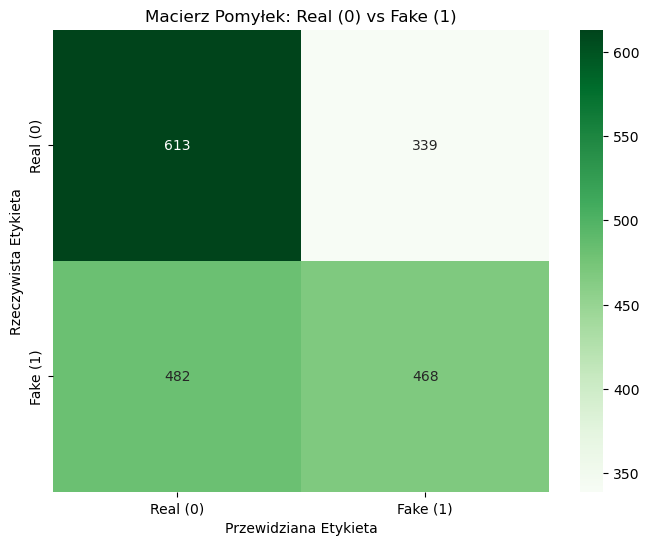

In [160]:
test_real_vs_fake_classification(
    discriminator_model=discriminator,
    test_df=df_test_CandC,
    layer_norm_L=layer_norm,
    combine_hidden_states_func=combine_hidden_states,
    device_L=device
)

In [161]:
# Zapisuje modele i ich parametry
model_dir = './saved_models'
import os
os.makedirs(model_dir, exist_ok=True)

gen_path = os.path.join(model_dir, 'generator.pt')
disc_path = os.path.join(model_dir, 'discriminator.pt')
gen_state_path = os.path.join(model_dir, 'generator_state_dict.pt')
disc_state_path = os.path.join(model_dir, 'discriminator_state_dict.pt')

# Zapis całych modeli
torch.save(generator, gen_path)
torch.save(discriminator, disc_path)
# Zapis samych parametrów
torch.save(generator.state_dict(), gen_state_path)
torch.save(discriminator.state_dict(), disc_state_path)

print(f'Zapisano generator: {gen_path}')
print(f'Zapisano dyskryminator: {disc_path}')
print(f'Zapisano parametry generatora: {gen_state_path}')
print(f'Zapisano parametry dyskryminatora: {disc_state_path}')

Zapisano generator: ./saved_models\generator.pt
Zapisano dyskryminator: ./saved_models\discriminator.pt
Zapisano parametry generatora: ./saved_models\generator_state_dict.pt
Zapisano parametry dyskryminatora: ./saved_models\discriminator_state_dict.pt


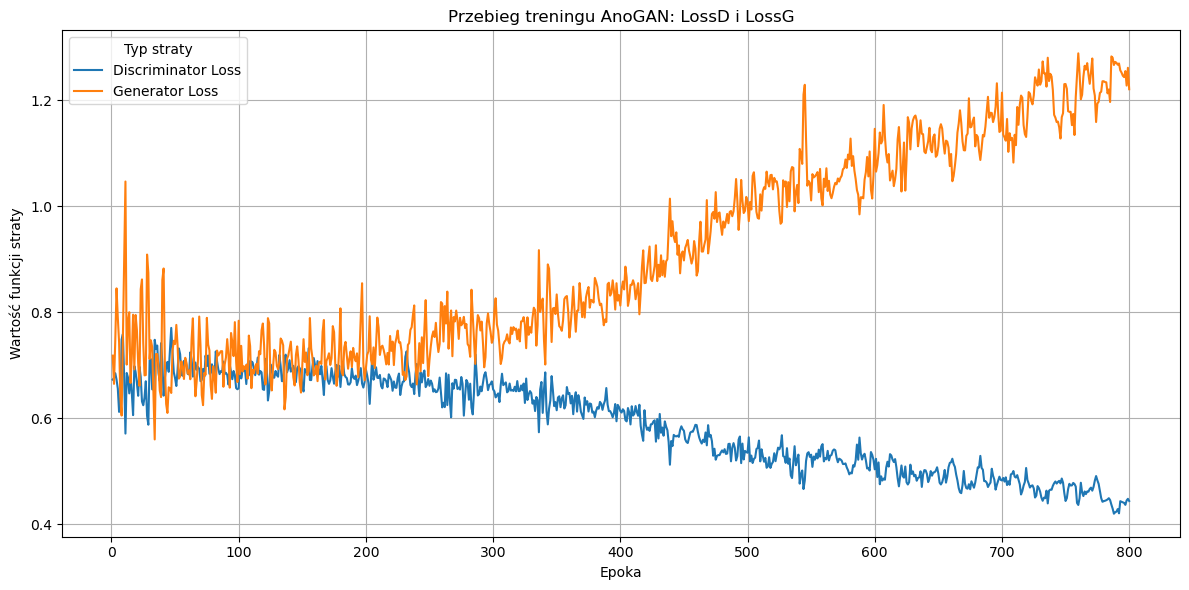

In [162]:

losses_df = pd.DataFrame({
    'Epoch': range(1, len(losses_D) + 1),
    'Discriminator Loss': losses_D,
    'Generator Loss': losses_G
})

losses_long = pd.melt(losses_df, id_vars=['Epoch'], value_vars=['Discriminator Loss', 'Generator Loss'],
                     var_name='Loss Type', value_name='Loss Value')

plt.figure(figsize=(12, 6))
sns.lineplot(data=losses_long, x='Epoch', y='Loss Value', hue='Loss Type')
plt.title('Przebieg treningu AnoGAN: LossD i LossG')
plt.xlabel('Epoka')
plt.ylabel('Wartość funkcji straty')
plt.legend(title='Typ straty')
plt.grid(True)
plt.tight_layout()
plt.show()